In [13]:
import pandas as pd
import numpy as np

# ==========================================
# DATA INGESTION & PREPROCESSING
# ==========================================

In [14]:
# Load the dataset

df = pd.read_csv('Nat_Gas.csv', parse_dates=['Dates'])
df = df.sort_values('Dates').reset_index(drop=True)

display(df.head())
display(df.describe())
display(df.shape)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_49936\265751897.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv('Nat_Gas.csv', parse_dates=['Dates'])


,Dates,Prices
0,2020-10-31,10.1
1,2020-11-30,10.3
2,2020-12-31,11.0
3,2021-01-31,10.9
4,2021-02-28,10.9


,Dates,Prices
count,48,48.000000
mean,2022-10-15 08:00:00,11.207083
min,2020-10-31 00:00:00,9.840000
25%,2021-10-23 06:00:00,10.650000
50%,2022-10-15 12:00:00,11.300000
75%,2023-10-07 18:00:00,11.625000
max,2024-09-30 00:00:00,12.800000
std,NaN,0.757897


(48, 2)

In [15]:
display(df.isnull().sum())

Dates     0
Prices    0
dtype: int64

In [16]:
# Define the start date (time t=0)
START_DATE = df['Dates'].min()

# Feature Engineering: Time variable (Days since start)
df['Days'] = (df['Dates'] - START_DATE).dt.days

display(df.head())

,Dates,Prices,Days
0,2020-10-31,10.1,0
1,2020-11-30,10.3,30
2,2020-12-31,11.0,61
3,2021-01-31,10.9,92
4,2021-02-28,10.9,120


In [17]:
# Feature Engineering: Fourier Terms for Seasonality
# Natural gas often has an annual cycle and a semi-annual cycle
PERIOD = 365.25 
df['Sin_Annual'] = np.sin(2 * np.pi * df['Days'] / PERIOD)
df['Cos_Annual'] = np.cos(2 * np.pi * df['Days'] / PERIOD)
df['Sin_Semi']   = np.sin(4 * np.pi * df['Days'] / PERIOD)
df['Cos_Semi']   = np.cos(4 * np.pi * df['Days'] / PERIOD)

display(df.head(15))

,Dates,Prices,Days,Sin_Annual,Cos_Annual,Sin_Semi,Cos_Semi
0,2020-10-31,10.10,0,0.000000,1.000000,0.000000,1.000000
1,2020-11-30,10.30,30,0.493468,0.869764,0.858402,0.512978
2,2020-12-31,11.00,61,0.867099,0.498137,0.863867,-0.503720
3,2021-01-31,10.90,92,0.999930,-0.011826,-0.023651,-0.999720
4,2021-02-28,10.90,120,0.880683,-0.473706,-0.834370,-0.551205
5,2021-03-31,10.90,151,0.517586,-0.855631,-0.885725,0.464210
6,2021-04-30,10.40,181,0.027950,-0.999609,-0.055879,0.998438
7,2021-05-31,9.84,212,-0.484089,-0.875019,0.847173,0.531317
8,2021-06-30,10.00,242,-0.852837,-0.522178,0.890665,-0.454661
9,2021-07-31,10.10,273,-0.999870,-0.016127,0.032249,-0.999480


# ==========================================
# STATISTICAL MODELING (HARMONIC REGRESSION)
# ==========================================

In [18]:
import statsmodels.api as sm

# Define predictors (X) and target (y)
X = df[['Days', 'Sin_Annual', 'Cos_Annual', 'Sin_Semi', 'Cos_Semi']]
X = sm.add_constant(X) # Adds the intercept
y = df['Prices']

# Fit Ordinary Least Squares (OLS) Regression
model = sm.OLS(y, X).fit()

# (Optional) Print summary to check statistical significance (p-values)
display(model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Prices   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.928
Method:                 Least Squares   F-statistic:                     122.3
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           6.69e-24
Time:                        00:29:31   Log-Likelihood:                 11.571
No. Observations:                  48   AIC:                            -11.14
Df Residuals:                      42   BIC:                           0.08455
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.1409      0.059    172.321      0.000      10.022      10.260
Days           0.0015   7.14e-05     20.834      0.000       0.001       0.002
Sin_Annual     0.6865      0.042     16.245      0.000       0.601       0.772
Cos_Annual    -0.0265      0.042     -0.636      0.528      -0.110       0.057
Sin_Semi      -0.0442      0.042     -1.061      0.295      -0.128       0.040
Cos_Semi      -0.0798      0.042     -1.923      0.061      -0.164       0.004
==============================================================================
Omnibus:                        0.504   Durbin-Watson:                   2.306
Prob(Omnibus):                  0.777   Jarque-Bera (JB):                0.541
Skew:                          -0.226   Prob(JB):                        0.763
Kurtosis:                       2.743   Cond. No.                     1.70e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.7e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""


# ==========================================
# THE ESTIMATION FUNCTION
# ==========================================

In [19]:
"""
    Estimates the price of natural gas for any given historical or future date.
    
    Parameters:
    input_date_str (str): Date in 'YYYY-MM-DD' format.
    
    Returns:
    float: Estimated price of natural gas.
"""

def get_price_estimate(input_date_str):

    target_date = pd.to_datetime(input_date_str)
    t = (target_date - START_DATE).days
    
    # Construct the feature array for the target date
    features = np.array([
        1.0,  # Constant (Intercept)
        t,    # Trend
        np.sin(2 * np.pi * t / PERIOD), # Sin Annual
        np.cos(2 * np.pi * t / PERIOD), # Cos Annual
        np.sin(4 * np.pi * t / PERIOD), # Sin Semi-Annual
        np.cos(4 * np.pi * t / PERIOD)  # Cos Semi-Annual
    ])
    
    # Calculate dot product of features and learned model coefficients
    estimated_price = np.dot(features, model.params)
    return round(estimated_price, 2)


# ==========================================
# VISUALIZATION: INTERPOLATION & EXTRAPOLATION
# ==========================================

In [20]:
from datetime import timedelta

# Create a continuous daily timeline from Oct 2020 to Sep 2025 (1 year extrapolation)
end_date = df['Dates'].max() + timedelta(days=365)
daily_dates = pd.date_range(start=START_DATE, end=end_date, freq='D')

# Generate predictions for every single day
predicted_prices = [get_price_estimate(date.strftime('%Y-%m-%d')) for date in daily_dates]


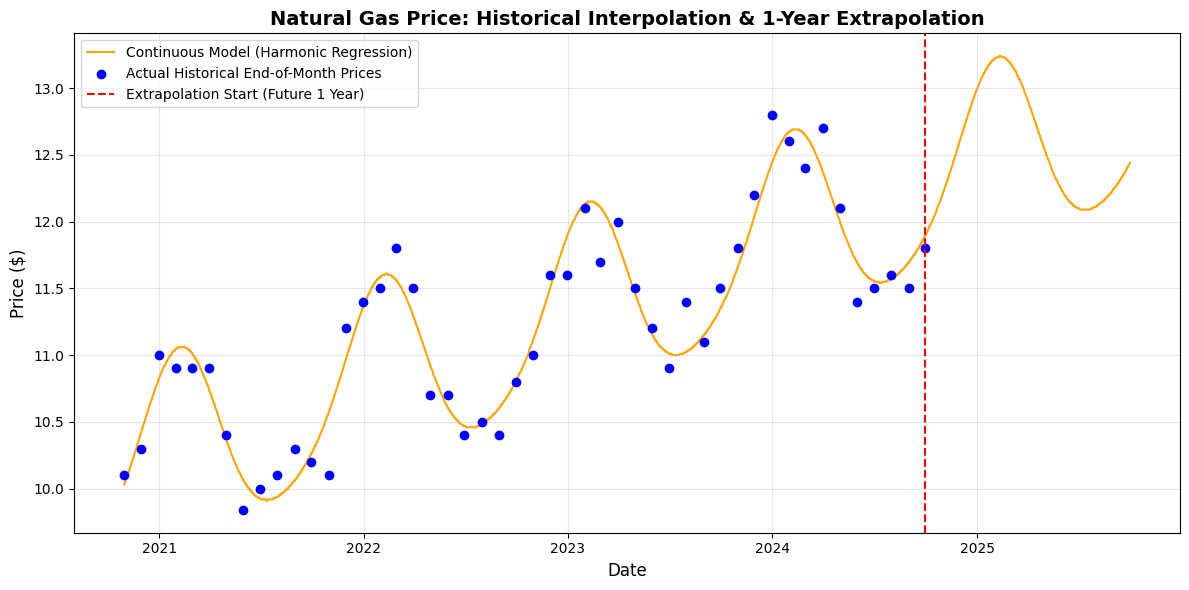

In [21]:

import matplotlib.pyplot as plt

# Plotting the results
plt.figure(figsize=(12, 6))

# Plot the continuous mathematical model
plt.plot(daily_dates, predicted_prices, color='orange', label='Continuous Model (Harmonic Regression)', zorder=1)

# Plot the actual historical data points
plt.scatter(df['Dates'], df['Prices'], color='blue', label='Actual Historical End-of-Month Prices', zorder=2)

# Formatting the plot
plt.axvline(x=df['Dates'].max(), color='red', linestyle='--', label='Extrapolation Start (Future 1 Year)')
plt.title('Natural Gas Price: Historical Interpolation & 1-Year Extrapolation', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



# ==========================================
# TESTING THE FUNCTION
# ==========================================

In [22]:

print(f"Historical Check (Mid-month interpolation) - 2022-02-14: ${get_price_estimate('2022-02-14')}")
print(f"Future Extrapolation (1 year ahead) - 2025-06-15: ${get_price_estimate('2025-06-15')}")

Historical Check (Mid-month interpolation) - 2022-02-14: $11.6
Future Extrapolation (1 year ahead) - 2025-06-15: $12.15


# ==========================================
# STORAGE CONTRACT PRICING MODEL
# ==========================================

In [23]:
import math
from datetime import datetime

def calculate_contract_value_upgraded(
    injection_dates,         # List of dates: ['2024-06-01', '2024-09-01']
    injection_volumes,       # List of volumes: [1000000, 500000]
    withdrawal_dates,        # List of dates: ['2024-08-01', '2025-01-01']
    withdrawal_volumes,      # List of volumes: [500000, 1000000]
    max_storage_volume,      # Max capacity of the facility
    max_injection_rate,      # Max allowed per transaction
    max_withdrawal_rate,     # Max allowed per transaction
    storage_cost_per_month,  # Fixed monthly rental fee
    injection_cost_per_mmbtu,# Cost to pump gas in
    withdrawal_cost_per_mmbtu,# Cost to pump gas out
    transport_cost_per_trip  # Fixed transport fee per date
):
    """
    Calculates the Net Value of a storage contract by dynamically forecasting 
    gas prices and processing all transactions in exact chronological order.
    """
    
    current_inventory = 0
    total_cash_flow = 0.0
    
    # ---------------------------------------------------------
    # 1. ORGANIZE CHRONOLOGICALLY
    # ---------------------------------------------------------
    # Combine all events into a single schedule list: (date, action, volume)
    schedule = []
    for i in range(len(injection_dates)):
        schedule.append((injection_dates[i], 'inject', injection_volumes[i]))
    for i in range(len(withdrawal_dates)):
        schedule.append((withdrawal_dates[i], 'withdraw', withdrawal_volumes[i]))
        
    # Sort the schedule chronologically by date
    schedule.sort(key=lambda x: datetime.strptime(x[0], "%Y-%m-%d"))

    # ---------------------------------------------------------
    # 2. PROCESS EVENTS IN EXACT TIME ORDER
    # ---------------------------------------------------------
    for date_str, action, volume in schedule:
        
        # INTEGRATION: Automatically forecast the price for this specific date
        # (Assumes get_price_estimate from Task 1 is already run in your notebook)
        price_on_date = get_price_estimate(date_str)
        
        if action == 'inject':
            # Constraint Checks
            if volume > max_injection_rate:
                raise ValueError(f"Injection volume ({volume}) on {date_str} exceeds max rate.")
            if current_inventory + volume > max_storage_volume:
                raise ValueError(f"Injecting {volume} on {date_str} exceeds capacity. Current inventory: {current_inventory}")
                
            current_inventory += volume
            
            # Cash Flow Updates (Money Out)
            gas_cost = volume * price_on_date
            inj_cost = volume * injection_cost_per_mmbtu
            total_cash_flow -= (gas_cost + inj_cost + transport_cost_per_trip)
            
            print(f"INJECTED: {volume:>10,} MMBtu on {date_str} @ est. ${price_on_date:<5} | Inv: {current_inventory:>10,}")

        elif action == 'withdraw':
            # Constraint Checks
            if volume > max_withdrawal_rate:
                raise ValueError(f"Withdrawal volume ({volume}) on {date_str} exceeds max rate.")
            if current_inventory - volume < 0:
                raise ValueError(f"Cannot withdraw {volume} on {date_str}. Only {current_inventory} in storage.")
                
            current_inventory -= volume
            
            # Cash Flow Updates (Money In)
            gas_revenue = volume * price_on_date
            wth_cost = volume * withdrawal_cost_per_mmbtu
            total_cash_flow += gas_revenue
            total_cash_flow -= (wth_cost + transport_cost_per_trip)
            
            print(f"WITHDREW: {volume:>10,} MMBtu on {date_str} @ est. ${price_on_date:<5} | Inv: {current_inventory:>10,}")

    # ---------------------------------------------------------
    # 3. PROCESS STORAGE RENT (Money Out)
    # ---------------------------------------------------------
    if schedule:
        # Since schedule is sorted, first and last items give us the exact date range
        min_date = datetime.strptime(schedule[0][0], "%Y-%m-%d")
        max_date = datetime.strptime(schedule[-1][0], "%Y-%m-%d")
        
        total_days_stored = (max_date - min_date).days
        total_months_stored = math.ceil(total_days_stored / 30.44) 
        
        total_storage_cost = total_months_stored * storage_cost_per_month
        total_cash_flow -= total_storage_cost
        
        print(f"RENTAL COST: {total_months_stored} months at ${storage_cost_per_month:,}/mo")

    return round(total_cash_flow, 2)




# ==========================================
# EXECUTE THE TEST (Interleaved Dates)
# ==========================================

In [24]:

print("\n--- Running Chronological Pricing Engine ---")

# Testing a complex schedule: Inject, then withdraw some, inject more, withdraw rest.
net_value = calculate_contract_value_upgraded(
    injection_dates=["2024-06-15", "2024-10-15"],   
    injection_volumes=[2000000, 1000000],           
    withdrawal_dates=["2024-08-15", "2025-01-15"],  
    withdrawal_volumes=[1000000, 2000000],          
    
    max_storage_volume=5000000,
    max_injection_rate=2000000,
    max_withdrawal_rate=2000000,
    
    storage_cost_per_month=100000,     # $100K / month rent
    injection_cost_per_mmbtu=0.01,     # $10K per 1M MMBtu
    withdrawal_cost_per_mmbtu=0.01,    # $10K per 1M MMBtu
    transport_cost_per_trip=50000      # $50K per trip
)

print("-" * 55)
print(f"FINAL CONTRACT NET VALUE: ${net_value:,.2f}")


--- Running Chronological Pricing Engine ---
INJECTED:  2,000,000 MMBtu on 2024-06-15 @ est. $11.6  | Inv:  2,000,000
WITHDREW:  1,000,000 MMBtu on 2024-08-15 @ est. $11.62 | Inv:  1,000,000
INJECTED:  1,000,000 MMBtu on 2024-10-15 @ est. $12.03 | Inv:  2,000,000
WITHDREW:  2,000,000 MMBtu on 2025-01-15 @ est. $13.13 | Inv:          0
RENTAL COST: 8 months at $100,000/mo
-------------------------------------------------------
FINAL CONTRACT NET VALUE: $1,590,000.00
